In [112]:
import gymnasium
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

print(gymnasium.__version__)

1.3.0


In [12]:
import gymnasium as gym

# Crear el entorno CartPole
env = gym.make("CartPole-v1", render_mode="human")  # muestra la ventana grafica

# Reset: Inicializa en un espacio aleatorio definido por gymnasium
obs, info = env.reset()  # reinicia el entorno
print("Observacion inicial:", obs)
print("Informacion inicial:", info)
env.close()

Observacion inicial: [-0.01285094 -0.04722478  0.01884101  0.00140394]
Informacion inicial: {}


s1


In [ ]:
# rgb_array permite capturar la imagen sin abrir una ventana externa.
env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)
frames = [env.render()]
terminated = truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    frames.append(env.render())

env.close()

# Convertir los fotogramas en una animacion embebida en Jupyter.
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(frames[0])
ax.axis("off")


def update(frame):
    image.set_data(frame)
    return (image,)


animation = FuncAnimation(
    fig, update, frames=frames, interval=40, blit=True, repeat=False
)
plt.close(fig)
HTML(animation.to_jshtml())

s2


In [17]:
import gymnasium as gym

env = gym.make("CartPole-v1")
obs, info = env.reset()  # inicio del episodio

total_reward: float = 0.0
done = False

while not done:
    # El agente elige una accion aleatoria
    action = env.action_space.sample()  # 0 o 1

    # El entorno ejecuta la accion
    obs, reward, terminated, truncated, info = env.step(action)
    # obs -> nueva observacion del entorno (numpy array)
    # reward -> recompensa obtenida (float)
    # terminated -> el episodio termino? (bool)
    # truncated -> se alcanzo el limite de pasos? (bool)
    # info -> informacion adicional (dict)

    total_reward += float(reward)
    done = terminated or truncated  # fin del episodio?

print(f"Recompensa total del episodio: {total_reward}")
env.close()
# Reto: mostrar animacion del cartpole

Recompensa total del episodio: 15.0


In [108]:
import gymnasium as gym

env = gym.make("CartPole-v1")
N_EPISODES = 100
rewards = []  # guardar recompensa de cada episodio

for episode in range(N_EPISODES):
    obs, info = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = 1 if obs[2] > 0 else 0  # accion basada en el angulo del palo
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += float(reward)
        done = truncated or terminated

    rewards.append(total_reward)
    print(f"Ep {episode+1:2d}: reward = {total_reward:.0f}")

print(f"Recompensa maxima: {max(rewards):.0f}")
print(f"Recompensa media: {sum(rewards)/len(rewards):.2f}")

Ep  1: reward = 39
Ep  2: reward = 41
Ep  3: reward = 56
Ep  4: reward = 41
Ep  5: reward = 37
Ep  6: reward = 47
Ep  7: reward = 25
Ep  8: reward = 35
Ep  9: reward = 49
Ep 10: reward = 43
Ep 11: reward = 45
Ep 12: reward = 35
Ep 13: reward = 40
Ep 14: reward = 39
Ep 15: reward = 41
Ep 16: reward = 50
Ep 17: reward = 46
Ep 18: reward = 47
Ep 19: reward = 25
Ep 20: reward = 31
Ep 21: reward = 36
Ep 22: reward = 51
Ep 23: reward = 27
Ep 24: reward = 41
Ep 25: reward = 34
Ep 26: reward = 39
Ep 27: reward = 26
Ep 28: reward = 24
Ep 29: reward = 64
Ep 30: reward = 49
Ep 31: reward = 31
Ep 32: reward = 39
Ep 33: reward = 34
Ep 34: reward = 45
Ep 35: reward = 41
Ep 36: reward = 41
Ep 37: reward = 40
Ep 38: reward = 45
Ep 39: reward = 26
Ep 40: reward = 55
Ep 41: reward = 27
Ep 42: reward = 34
Ep 43: reward = 39
Ep 44: reward = 35
Ep 45: reward = 31
Ep 46: reward = 55
Ep 47: reward = 46
Ep 48: reward = 58
Ep 49: reward = 31
Ep 50: reward = 50
Ep 51: reward = 58
Ep 52: reward = 56
Ep 53: rewar

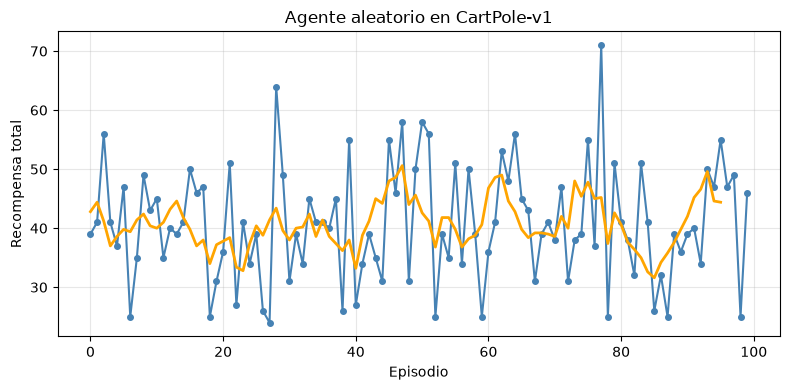

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# Graficar recompensas
plt.figure(figsize=(8, 4))
plt.plot(rewards, color="steelblue", linewidth=1.5, marker="o", markersize=4)

# Linea de media movil
media = np.convolve(rewards, np.ones(5) / 5, mode="valid")
plt.plot(media, color="orange", lw=2)

plt.xlabel("Episodio")
plt.ylabel("Recompensa total")
plt.title("Agente aleatorio en CartPole-v1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## D3


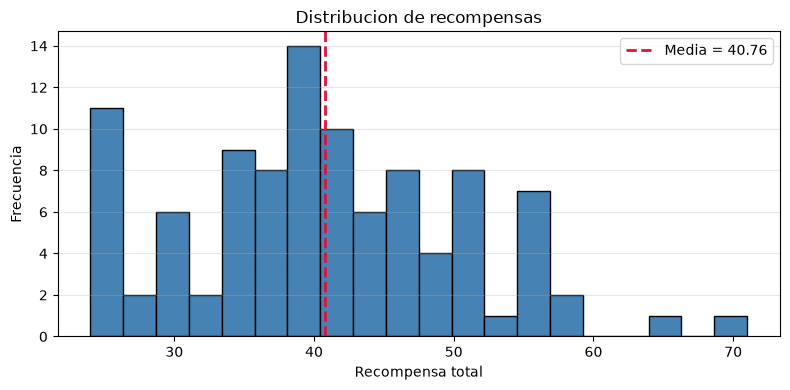

In [ ]:
media = np.mean(rewards)

plt.figure(figsize=(8, 4))
plt.hist(rewards, bins=20, color="steelblue", edgecolor="black")
plt.axvline(
    media, color="crimson", linestyle="--", linewidth=2, label=f"Media = {media:.2f}"
)
plt.xlabel("Recompensa total")
plt.ylabel("Frecuencia")
plt.title("Distribucion de recompensas")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## D2


In [ ]:
env = gym.make("Blackjack-v1", render_mode="human")

obs, info = env.reset()
print("Observacion inicial:", obs)
env.close()

# The observation consists of a 3-tuple containing: the player’s current sum, the value of the dealer’s one showing card (1-10 where 1 is ace), and whether the player holds a usable ace (0 or 1).
# The observation is returned as (int(), int(), int()).

Observacion inicial: (8, 1, 0)


Exploracion Libre


In [105]:
import gymnasium as gym

env = gym.make("MountainCar-v0")
rewards = []
for episode in range(10):
    obs = env.reset()
    total = 0
    done = False
while not done:
    # Acción aleatoria
    action = env.action_space.sample()
    obs, reward, terminated, truncated, _ = env.step(action)
    total += reward
    done = terminated or truncated
rewards.append(total)
print(f"Ep {episode+1}: reward = {total:.0f}")

Ep 10: reward = -200


In [ ]:
print([env_id for env_id in gym.envs.registry.keys()])

['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Acrobot-v1', 'phys2d/CartPole-v0', 'phys2d/CartPole-v1', 'phys2d/Pendulum-v0', 'LunarLander-v3', 'LunarLanderContinuous-v3', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'CarRacing-v3', 'Blackjack-v1', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'CliffWalking-v0', 'Taxi-v3', 'tabular/Blackjack-v0', 'tabular/CliffWalking-v0', 'Reacher-v2', 'Reacher-v4', 'Reacher-v5', 'Pusher-v2', 'Pusher-v4', 'Pusher-v5', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedPendulum-v5', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'InvertedDoublePendulum-v5', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'HalfCheetah-v5', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Hopper-v5', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Swimmer-v5', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4', 'Walker2d-v5', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', 'Humanoid-v2', 'Humanoid-v3', 'Humanoid-v4', 'Humanoid-v5', 'Humano